# SPRINT 11

Aquesta pràctica integra l'ús de Python amb les llibreries Pandas, Matplotlib, Seaborn o Plotly, així com la seva integració amb Power BI. Treballaràs tot el procés des de la connexió a MySQL, la creació de visualitzacions avançades en Python i finalment la incorporació d'aquestes visualitzacions a un informe dinàmic a Power BI.

## Nivell 1


### Exercici 1

Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

#### Importante:

Muy importante: Por motivos de seguridad, todos los datos de conexión los guardaré en un archivo .env que contendrá las contraseñas, usuarios, etc. Lo colocaré en la raíz del proyecto, pero no se subirá a GitHub gracias al archivo .gitignore. Es la forma segura de realizar este tipo de conexiones.

Para realizar el ejercicio 1, y en general para todo el tema de las conexiones a bases de datos, utilizaré la librería SQLAlchemy, ya que es una solución más utilizada actualmente y ofrece mayores ventajas si posteriormente quisiera conectarme a otras bases de datos.

In [4]:
# 1. Cargar las librerias necesarias

import os
import pandas as pd

from sqlalchemy import create_engine, text, inspect 
from sqlalchemy.exc import SQLAlchemyError
from dotenv import load_dotenv  # para las variables de entorno seguras

In [5]:
# REalizar la conexión segura

# leer y cargar variables del .env

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")   


# crear conexión con

try:

    engine = create_engine(
        f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

    with engine.connect() as connection:

        connection.execute(text("SELECT 1"))

    print("Conexión exitosa")

except SQLAlchemyError as e:

    print(f"Error de conexión: {e}")

Conexión exitosa


In [6]:
# Obtener las tablas de mySQL starmarketplace

inspector = inspect(engine)

tablas = inspector.get_table_names()

print(tablas)

['companies', 'credit_card_activated', 'credit_cards', 'products', 'transaction_product', 'transactions', 'users']


In [7]:
# importar las tablas de MySQL las guardo en el diccionario dataframe 
# así mantengo los originales seguros en mi Python y puedo recuperar 
# cuando necesite sin necesidad de conectar conla DB

dataframes = {}

for tabla in tablas:
    dataframes[tabla] = pd.read_sql(f"SELECT * FROM {tabla}", engine)

print(dataframes.keys())

dict_keys(['companies', 'credit_card_activated', 'credit_cards', 'products', 'transaction_product', 'transactions', 'users'])


In [8]:
for nombre, df in dataframes.items():
    print(f"{nombre}: {df.shape}")

companies: (100, 6)
credit_card_activated: (5000, 2)
credit_cards: (5000, 9)
products: (100, 6)
transaction_product: (253391, 3)
transactions: (100000, 10)
users: (5000, 11)


In [9]:
# cierro conexion, ya no necesito y libero recursos

engine.dispose()
print("Conexión creada")

Conexión creada


In [10]:
# saco los dataframes de las tablas del diccionario

df_companies = dataframes["companies"]
df_credit_card_activated = dataframes["credit_card_activated"]
df_credit_cards = dataframes["credit_cards"]
df_products = dataframes["products"]
df_transaction_product = dataframes["transaction_product"]
df_transactions = dataframes["transactions"]
df_users = dataframes["users"]

### Exercici 2

Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

- Una variable numèrica.
- Dues variables numèriques.
- Una variable categòrica.
- Una variable categòrica i una numèrica.
- Dues variables categòriques.
- Tres variables combinades.
- Crea un Pairplot.

In [12]:
# importar librerias de visualizacion matplotlib , seaborn y plotly

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#### Una variable numérica.

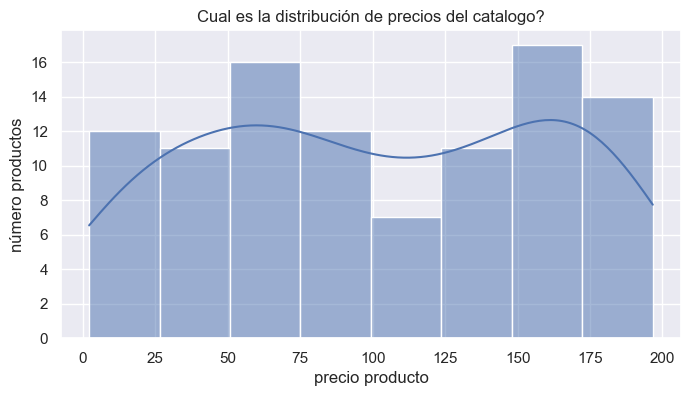

In [13]:
# Para la variable numérica analizo la distribución de precios 
# de los productos del catalogo. Uso histograma 

sns.set_theme(style="darkgrid")
plt.figure(figsize=(8,4), dpi=100)

sns.histplot(
    data = df_products,
    x = "price",
    kde=True
)

plt.title("Cual es la distribución de precios del catalogo?") # definir título
plt.xlabel("precio producto") # definir el nombre del eje X
plt.ylabel("número productos"); # definir el nombre del eje Y

plt.show()

Interpretación resultado: El resultado de este histograma muestra una distribución bastante uniforme a lo largo de todo el rango de precios.
Esto indica que por lo general tenemos productos en el catalogo de forma equilibrada para todo el rango, con dos rangos que destacan un poco mas con aproximadamente 16 productos (50-75 y 150-175) y un rango de precios central (100-125), que destaca por la poca cantidad de productos que alberga, solo 7 productos. 

#### Dos variables numéricas.

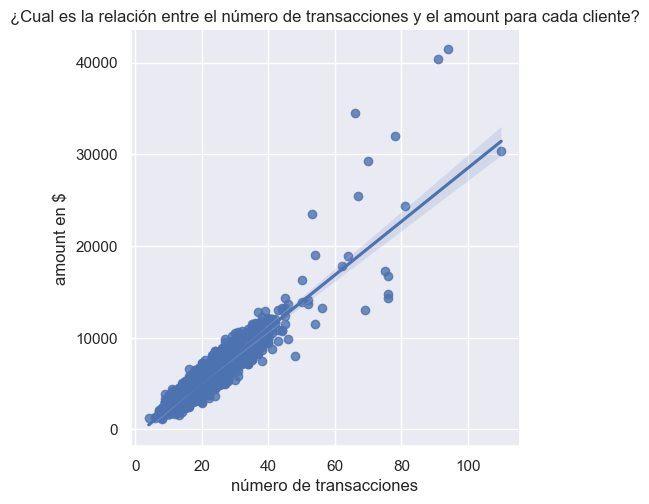

In [14]:

ventas_user = (df_transactions.groupby("user_id")[["amount"]].sum()).reset_index()
transacciones_user = (df_transactions.groupby("user_id")[["id"]].count()).reset_index()

df_resumen = ventas_user.merge(transacciones_user, on="user_id")
#df_resumen = df_resumen.rename(columns = {"amount":"ventas", "id":"transacciones"})


sns.set_theme(style="darkgrid")
sns.lmplot(
    data = df_resumen,
    x = "id",
    y = "amount",
)

plt.title("¿Cual es la relación entre el número de transacciones y el amount para cada cliente?") # definir título
plt.xlabel("número de transacciones") # definir el nombre del eje X
plt.ylabel("amount en $"); # definir el nombre del eje Y

plt.show()


Interpretación resultado: El gráfico demuestra claramente que existe una relación directa entre el numero de transacciones que realiza cada usuario y el total amount de cada usuario. Cuantas más transacciones mayor es el amount.

#### Una variable categórica

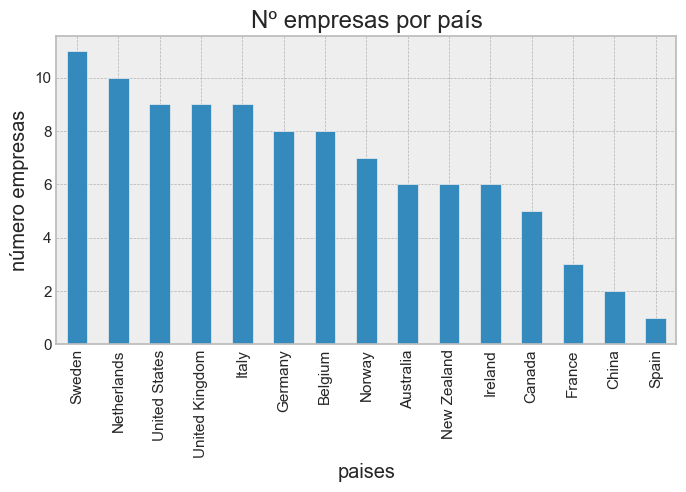

In [15]:
# Para una variable categorica hay varias opciones barras o treemap serian las más recomendables.
# En este caso debido al reducido número de datos a analizar (100) y datos únicos, 
# el gráfico de barras ayudará a mostrar información.

plt.style.use('bmh')   # le doy un toque de estilo
plt.figure(figsize=(8,4), dpi=100)

df_companies["country"].value_counts().plot.bar()

plt.title("Nº empresas por país") # definir título
plt.xlabel("paises") # definir el nombre del eje X
plt.ylabel("número empresas"); # definir el nombre del eje Y

Interpretación resultado: El gráfico muestra que Sweden es el país con mayor número de companies en el marketplace, unas 11 companies, mientras que Spain, China y France son las que menos companies tienen en el marketplace, entre 1 y 3 companies.

#### Una variable categórica y una numérica.

In [16]:
# Cantidad de transacciones por empresa Top 20

# calculo transacciones para cada compañía

df_transaction_company = df_transactions.groupby("company_id").agg(
    num_transacciones=("id" , "count")).sort_values(
        by="num_transacciones", ascending=False).head(20).reset_index()
df_transaction_company

# merge transactio_company con companies para tener nombre

df_merge = df_transaction_company.merge(
    df_companies[["company_id", "company_name"]],
    on = "company_id"
    )

df_merge

,company_id,num_transacciones,company_name
0,b-2222,2401,Ac Fermentum Incorporated
1,b-2302,1599,Nunc Interdum Incorporated
2,b-2330,1593,Donec Fringilla PC
3,b-2366,1586,Mauris Institute
4,b-2614,1585,Rutrum Non Inc.
5,b-2350,1583,Aliquet Vel Vulputate Incorporated
6,b-2566,1576,Aliquam PC
7,b-2574,1567,Orci Adipiscing Limited
8,b-2478,1566,Etiam Bibendum Fermentum Industries
9,b-2550,1564,Auctor Mauris Corp.


In [17]:
import plotly.io as pio
pio.templates


fig = px.bar(df_merge, x='company_name', y='num_transacciones',
             hover_data=['num_transacciones', 'company_id'], 
             #range_y=(1000, 2500),
             range_color=(1500, 1700),
             color='num_transacciones',
             color_continuous_scale='Peach',
             template = 'seaborn',
             labels={'num_transacciones':'número transacciones', 'company_name':'compañías'}, 
             height=600,
             width= 1100,
             title="Cual es el número de transacciones realizadas por compañía?"
             )

fig.show()

Interpretación resultado: El gráfico muestra que AC Fermentum es la compañía que lidera el número de transacciones de manera destacada del resto de compañias del Top 20. También podemos decir que exceptuando AC Fermentum, el Top 20 de compañias tienen apenas diferencia, en el computo total de transacciones realizadas en los años de estudio.

#### Dos variables categóricas

In [18]:
# Voy a comparar e intentar encontrar si hay alguna relación entre el país donde viven los usuarios y
#  el país donde se ubica la compañia, la pregunta sería : ¿Los usuarios compran más en compañías de su mismo país?
# haré merge de 3 tablas y usare un heatmap de seaborn para mostrar la dependencia. Usaré también crosstab

pais_company = df_companies[["company_id","country"]]
pais_user = df_users[["id","country"]]
transacciones = df_transactions[["id", "amount", "user_id", "company_id"]]

df_merge = transacciones.merge(
    pais_company,
    on = "company_id"
)
transacciones = df_merge.merge(
    pais_user,
    left_on = "user_id",
    right_on = "id"
)

transacciones = transacciones.rename(
    columns = {
        'id_x':'id', 
        'country_x':'country_company', 
        'country_y':'country_user'
    }).drop(columns=['id_y'])

# vamos a hacer el crosstab

cross = pd.crosstab(
    transacciones["country_user"],
    transacciones["country_company"]
)

display(cross)

country_company,Australia,Belgium,Canada,China,France,Germany,Ireland,Italy,Netherlands,New Zealand,Norway,Spain,Sweden,United Kingdom,United States
country_user,,,,,,,,,,,,,,,
Canada,1165,1649,970,422,0,0,1244,0,0,1217,1414,0,0,0,1905
France,0,0,0,0,534,1419,0,1452,1662,0,0,167,1788,1484,0
Germany,0,0,0,0,502,1478,0,1531,1678,0,0,176,1812,1546,0
Italy,0,0,0,0,478,1448,0,1465,1623,0,0,189,1841,1522,0
Netherlands,0,0,0,0,560,1444,0,1602,1731,0,0,177,1848,1599,0
Poland,0,0,0,0,517,1433,0,1434,1537,0,0,162,1725,1466,0
Portugal,0,0,0,0,520,1540,0,1478,1760,0,0,151,1812,1504,0
Spain,0,0,0,0,552,1459,0,1546,1737,0,0,156,1940,1570,0
Sweden,0,0,0,0,473,1370,0,1389,1571,0,0,167,1729,1417,0


In [19]:

cross_porcentaje= pd.crosstab(
    transacciones["country_user"],
    transacciones["country_company"],
    normalize= True
) *100

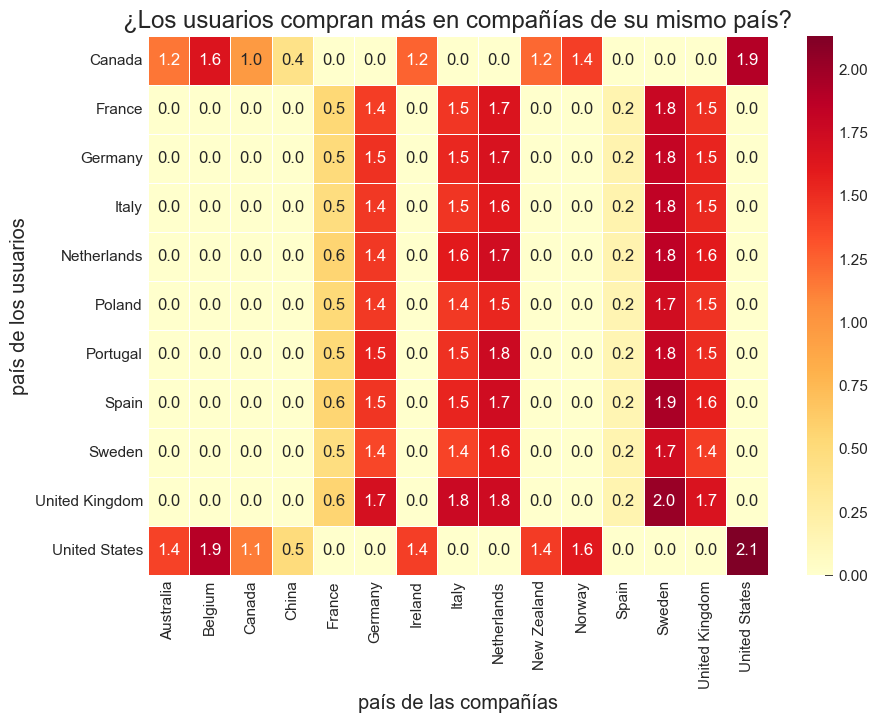

In [20]:
f, ax = plt.subplots(figsize=(10, 7))

sns.set_palette("flare")
sns.heatmap(cross_porcentaje, annot=True, fmt=".1f", linewidths=.5, ax=ax, cmap="YlOrRd")
ax.set_title("¿Los usuarios compran más en compañías de su mismo país?")
ax.set_ylabel("país de los usuarios")
ax.set_xlabel("país de las compañías");

Interpretación resultado: Según lo que nos muestra el Heatmap podemos afirmar que mayoritariamente no existe una relación directa entre el país del usuario con el echo de que hagan más transacciones con empresas de su país. Hay dos excepciones que son United States y Sweden que si cumplirían la premisa. 

Realmente con este heatmap lo que se aprecia es que los cinco paises con mayor número de transacciones, son donde mayoritariamente compran los usuarios de todos los paises, exceptuando los canadienses y los de United States, donde hay muchos paises que no venden nada por lo que su comportamiento es diferente.

#### Tres variables combinadas

In [21]:
# longitud - latitud - Amount : El amount va a ser la suma de amounts en la misma latitud-longitud geográfica, 
# pero limitada a grados exactos, ya que debido a la alta precision original de este df con 100.000 valores distinto,
# he reducido a grados para unir amounts cercanas en zonas (69 zonas)

df_map = df_transactions[["lat","longitude","amount"]]

df_map["lat"] = df_map["lat"].round(0)
df_map["longitude"] = df_map["longitude"].round(0)

df_map = df_map.groupby(["lat","longitude"])["amount"].sum().reset_index()
display(df_map)

,lat,longitude,amount
0,29.0,-99.0,55693.03
1,29.0,-98.0,249118.26
2,30.0,-95.0,250001.56
3,33.0,-117.0,266480.13
4,33.0,-112.0,292803.44
...,...,...,...
64,60.0,17.0,347131.29
65,60.0,18.0,464864.85
66,60.0,19.0,800017.69
67,61.0,18.0,63060.76


In [22]:
# Uso scatter_geo de plotly para mostrar las tres cariables "numéricas" en un mapa, 
# la geolocalización y el amount de la zona. El hover o tooltip muestra 
# las 3 magnitudes "lat", "longitude" y "amount".

fig = px.scatter_geo(df_map, 
                     lat='lat',
                     lon='longitude',
                     color="amount", # which column to use to set the color of markers
                     size="amount"# size of markers
                     )
fig.show()

Interpretación resultado: El scatter_geo nos muestra que las ventas de las compañías se han limitado a dos continentes determinados, Norte America y Europa. Además podemos distinguir claramente que el volumen de ventas en europa es mucho mayor que en Norte America. 

Además podemos identificar por color y tamaño del punto las ventas acumuladas en una zona concreta de Polonia es el mayor, aunque UK, España, Netherlands y Germany tienen mayor densidad de puntos de gran tamaño. 

Si hacemos analisis por paises, debido al gran numero de paises en Europa, United States y Canada tienen mayores ventas por país aunque mucho más dispersas por territorio.

#### Crea un Pairplot

In [23]:
# Recargo los df_ del diccionario y creo un df_ con todos las columnas que quiero analizar
df_companies = dataframes["companies"]
df_products = dataframes["products"]
df_transaction_product = dataframes["transaction_product"]
df_transactions = dataframes["transactions"]
df_users = dataframes["users"]

pais_company = (
    df_companies[["company_id", "country"]]
    .rename(columns={"country": "country_company"})
)

pais_user = (
    df_users[["id", "country"]]
    .rename(columns={"id": "user_id",
                     "country": "country_user" })
)

df_merge = (
    df_transactions[["id", "timestamp", "declined", "amount", "user_id", "company_id"]]
    .merge(pais_company, on="company_id")
    .merge(pais_user, on="user_id")
)

df_transaction_product = (
    df_transaction_product
    .rename(columns={"transaction_id":"id"})
)

df_products = (
    df_products
    .rename(columns={"id":"product_id"})
    .drop(columns="warehouse_id")             
)

df_transacciones = (
    df_transaction_product[['id','product_id']]
    .merge(df_merge, on="id", how="left")
    .merge(df_products, on="product_id")
)

display(df_transacciones)

,id,product_id,timestamp,declined,amount,user_id,company_id,country_company,country_user,product_name,price,colour,weight
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,2024-08-28 07:16:46,0,395.43,4713,b-2458,Netherlands,France,the duel warden,180.91,#666666,3.0
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26,2024-08-28 07:16:46,0,395.43,4713,b-2458,Netherlands,France,Stark Karstark,53.01,#898989,2.0
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87,2024-08-28 07:16:46,0,395.43,4713,b-2458,Netherlands,France,sith Jade,96.26,#e2e2e2,1.5
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97,2024-08-28 07:16:46,0,395.43,4713,b-2458,Netherlands,France,jinn Winterfell,65.25,#bababa,1.0
4,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,66,2016-12-21 20:07:18,0,155.63,438,b-2370,Sweden,Italy,mustafar jinn,2.12,#545454,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
253386,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,16,2019-10-30 02:31:37,0,234.22,1008,b-2302,Germany,Sweden,the duel warden,180.91,#666666,3.0
253387,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,49,2019-10-30 02:31:37,0,234.22,1008,b-2302,Germany,Sweden,the giantsblood maester,53.31,#e2e2e2,1.0
253388,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,18,2023-06-17 19:10:30,0,148.91,680,b-2250,Italy,Netherlands,Karstark warden,148.91,#c4c4c4,0.8
253389,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,26,2021-08-05 12:26:24,0,74.54,1103,b-2450,Netherlands,United Kingdom,Stark Karstark,53.01,#898989,2.0


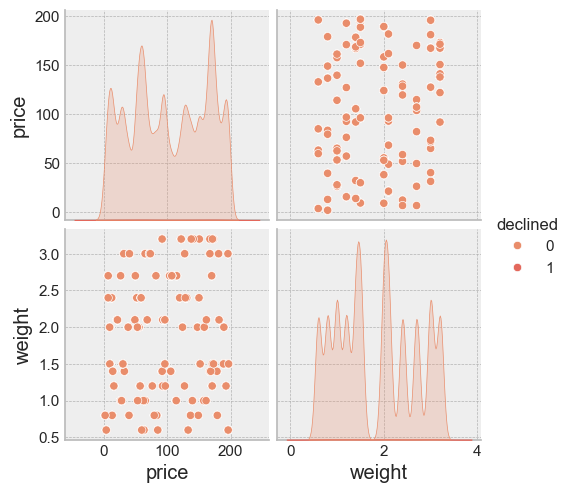

In [27]:
sns.pairplot(df_transacciones[["price", "weight", "declined"]], hue="declined"
)

In [25]:
df_resultante = (
    df_transacciones
    .groupby(["product_name", "colour"])
    .agg(
        total_qty=("product_id", "count"),
        total_amount=("amount", "sum"),
        precio=("price", "first"),
        weight=("weight", "first")
    )
    .sort_values("total_amount", ascending=False)
)

display(df_resultante)

,,total_qty,total_amount,precio,weight
product_name,colour,,,,
Winterfell,#1c1c1c,2552,1028840.03,195.94,0.6
warden,#a0a0a0,2571,1028268.55,196.65,1.5
Direwolf,#b7b7b7,2568,1024569.86,195.62,3.0
duel Direwolf,#a8a8a8,2558,1009926.46,181.60,2.1
Stannis warden,#dbdbdb,2535,1008528.62,194.29,1.5
...,...,...,...,...,...
riverlands north Direwolf,#c1c1c1,2525,551613.81,6.90,2.7
mustafar jinn,#545454,2601,546203.97,2.12,0.8
giantsblood maester Karstark,#f9f9f9,2461,541806.74,9.46,1.5


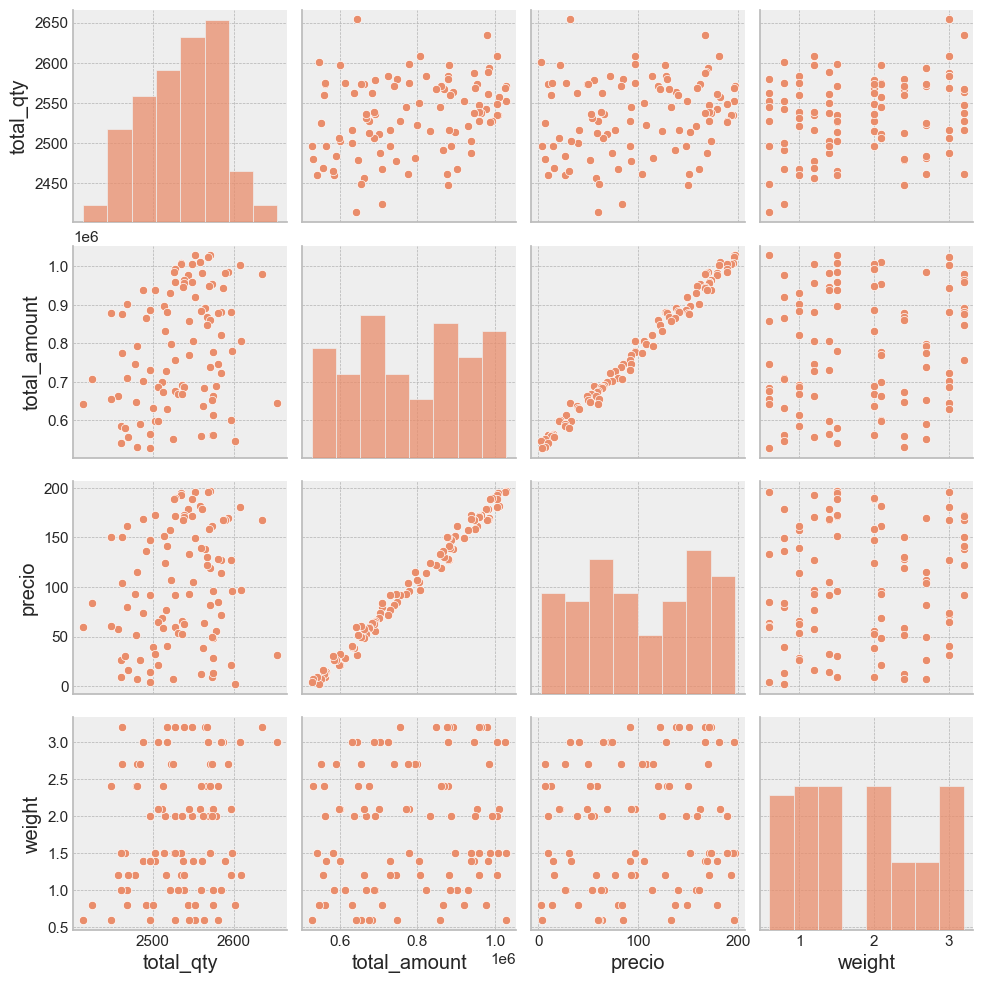

In [26]:
sns.pairplot(df_resultante[["total_qty","total_amount",	"precio","weight"]]
);

In [ ]:
df_transactions

In [ ]:
# Visualización de companies. En una tabla de dimensiones y no tiene variables numéricas
# Elijo el campo de categoria "country" para contar cuantas companies hay en cada pais

df_companies["country"].value_counts()

In [ ]:
# df_credit_card_activated tiene una variable booleana (Categorica nominal) en este caso lo ideal será un pie sobre valores contados

df_credit_card_activated["activated"].value_counts()

In [ ]:

plt.style.use('ggplot')   # le doy un toque de estilo
plt.figure(figsize=(5,5), dpi=100)

df_credit_card_activated["activated"].value_counts().plot.pie(
    labels=("Activas", "Desactivadas"), 
    autopct='%1.2f%%', 
    startangle = 90
    )

plt.title("Tarjetas activadas") # definir título
plt.legend(title="activated", bbox_to_anchor=(1.05,1));

In [ ]:
# Para df_credit_cards utilizare la expiring_date para realizar la visualización
import datetime as dt

df_credit_cards["expiring_date"] = pd.to_datetime(df_credit_cards["expiring_date"])
df_credit_cards.groupby(df_credit_cards["expiring_date"].dt.year).size()

In [ ]:
# Finalmente para este campo de fecha ideal usar un gráfico de barras que permite 
# comparar facilmente la caducidad de las tarjetas

plt.style.use('bmh')   # le doy un toque de estilo
plt.figure(figsize=(8,4), dpi=100)

df_credit_cards.groupby(df_credit_cards["expiring_date"].dt.year).size().plot.bar()

plt.title("Cuando caducan las tarjetas?") # definir título
plt.xlabel("año caducidad") # definir el nombre del eje X
plt.ylabel("número tarjetas") # definir el nombre del eje Y
plt.xticks(rotation=45);

In [ ]:
# Voy a contar la cantidad de unidades vendidas de cada producto y mostraré el top 20

df_transaction_product = dataframes["transaction_product"]

plt.style.use('bmh')   # le doy un toque de estilo
plt.figure(figsize=(8,4), dpi=100)

df_transaction_product["product_id"].value_counts().head(20).plot.bar()

plt.title("Top 20 - Productos más vendidos? ") # definir título
plt.xlabel("referencia producto") # definir el nombre del eje X
plt.ylabel("unidades vendidas"); # definir el nombre del eje Y

In [ ]:
#sns.pairplot(df_transactions, vars=["company_id", "amount", "user_id"]);

df_transactions.groupby("company_id")[["amount"]].sum().sort_values(by="amount", ascending=False)